# Healthcare Risk Prediction System

# Phase 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import joblib
import os

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

# Paths
DATA_PATH = '../datasets/'
MODEL_PATH = '../models/'
os.makedirs(MODEL_PATH, exist_ok=True)


# Phase 2 — Data Analysis
## 2.1 Load Datasets

In [2]:
df_diabetes = pd.read_csv(DATA_PATH + 'diabetes.csv')
df_heart    = pd.read_csv(DATA_PATH + 'heart.csv')

print(f'   Diabetes : {df_diabetes.shape}')
print(f'   Heart    : {df_heart.shape}')

   Diabetes : (768, 9)
   Heart    : (1025, 14)


## 2.2 Diabetes Dataset — Full Analysis

In [3]:
print('=' * 55)
print('         DIABETES DATASET ')
print('=' * 55)
print(f'Shape   : {df_diabetes.shape}  (rows x columns)')
print(f'Size    : {df_diabetes.size}   (total elements)')
print(f'Columns : {list(df_diabetes.columns)}')

         DIABETES DATASET 
Shape   : (768, 9)  (rows x columns)
Size    : 6912   (total elements)
Columns : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [4]:
print('--- HEAD (first 5 rows) ---')
df_diabetes.head()

--- HEAD (first 5 rows) ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print('--- TAIL (last 5 rows) ---')
df_diabetes.tail()

--- TAIL (last 5 rows) ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
print('--- DATA TYPES ---')
print(df_diabetes.dtypes)

--- DATA TYPES ---
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [7]:
print('--- INFO ---')
df_diabetes.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
print('--- STATISTICAL DESCRIPTION ---')
df_diabetes.describe().round(2)

--- STATISTICAL DESCRIPTION ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [9]:
print('--- MISSING VALUES (actual NaN) ---')
print(df_diabetes.isnull().sum())
print(f'\nDuplicate rows: {df_diabetes.duplicated().sum()}')
print('\n--- HIDDEN ZERO CHECK (biologically impossible zeros) ---')
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    cnt = (df_diabetes[col] == 0).sum()
    pct = cnt / len(df_diabetes) * 100
    print(f'  {col:20s}: {cnt:3d} zeros  ({pct:.1f}%)')

--- MISSING VALUES (actual NaN) ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0

--- HIDDEN ZERO CHECK (biologically impossible zeros) ---
  Glucose             :   5 zeros  (0.7%)
  BloodPressure       :  35 zeros  (4.6%)
  SkinThickness       : 227 zeros  (29.6%)
  Insulin             : 374 zeros  (48.7%)
  BMI                 :  11 zeros  (1.4%)


In [10]:
print('--- TARGET DISTRIBUTION ---')
print(df_diabetes['Outcome'].value_counts())
print(df_diabetes['Outcome'].value_counts(normalize=True).round(3) * 100)

--- TARGET DISTRIBUTION ---
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


## 2.3 Heart Disease Dataset — Full Analysis

In [11]:
print('=' * 55)
print('         HEART DISEASE DATASET')
print('=' * 55)
print(f'Shape   : {df_heart.shape}  (rows x columns)')
print(f'Size    : {df_heart.size}   (total elements)')
print(f'Columns : {list(df_heart.columns)}')

         HEART DISEASE DATASET
Shape   : (1025, 14)  (rows x columns)
Size    : 14350   (total elements)
Columns : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [12]:
print('--- HEAD (first 5 rows) ---')
df_heart.head()

--- HEAD (first 5 rows) ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
print('--- TAIL (last 5 rows) ---')
df_heart.tail()

--- TAIL (last 5 rows) ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [14]:
print('--- DATA TYPES ---')
print(df_heart.dtypes)

--- DATA TYPES ---
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [15]:
print('--- INFO ---')
df_heart.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
print('--- STATISTICAL DESCRIPTION ---')
df_heart.describe().round(2)

--- STATISTICAL DESCRIPTION ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [17]:
print('--- MISSING VALUES ---')
print(df_heart.isnull().sum())
print(f'\nDuplicate rows: {df_heart.duplicated().sum()}')
print('\n--- CATEGORICAL COLUMNS UNIQUE VALUES ---')
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
for col in cat_cols:
    print(f'  {col:10s}: {sorted(df_heart[col].unique())}')

--- MISSING VALUES ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 723

--- CATEGORICAL COLUMNS UNIQUE VALUES ---
  sex       : [np.int64(0), np.int64(1)]
  cp        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  fbs       : [np.int64(0), np.int64(1)]
  restecg   : [np.int64(0), np.int64(1), np.int64(2)]
  exang     : [np.int64(0), np.int64(1)]
  slope     : [np.int64(0), np.int64(1), np.int64(2)]
  ca        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  thal      : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [18]:
print('--- TARGET DISTRIBUTION ---')
print(df_heart['target'].value_counts())
print(df_heart['target'].value_counts(normalize=True).round(3) * 100)

--- TARGET DISTRIBUTION ---
target
1    526
0    499
Name: count, dtype: int64
target
1    51.3
0    48.7
Name: proportion, dtype: float64


# Phase 3 — Preprocessing
## 3.1 Diabetes Preprocessing

In [19]:
diab = df_diabetes.copy()

# --- Step 1: Replace hidden zeros with NaN ---
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
diab[zero_cols] = diab[zero_cols].replace(0, np.nan)
print('After replacing zeros with NaN:')
print(diab[zero_cols].isnull().sum())

After replacing zeros with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [20]:
# --- Step 2: Median imputation ---
for col in zero_cols:
    median_val = diab[col].median()
    diab[col].fillna(median_val, inplace=True)
    print(f'  {col:20s} filled with median = {median_val:.2f}')
print('\nMissing values after imputation:')
print(diab.isnull().sum())

  Glucose              filled with median = 117.00
  BloodPressure        filled with median = 72.00
  SkinThickness        filled with median = 29.00
  Insulin              filled with median = 125.00
  BMI                  filled with median = 32.30

Missing values after imputation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [21]:
# --- Step 3: IQR Outlier Capping (no rows dropped!) ---
feature_cols_d = [c for c in diab.columns if c != 'Outcome']
print('Outlier capping (IQR method):')
for col in feature_cols_d:
    Q1  = diab[col].quantile(0.25)
    Q3  = diab[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    before = ((diab[col] < lo) | (diab[col] > hi)).sum()
    diab[col] = diab[col].clip(lower=lo, upper=hi)
    print(f'  {col:25s}: {before} outliers capped')
print(f'\nTotal rows preserved: {len(diab)} ✅')

Outlier capping (IQR method):


  Pregnancies              : 4 outliers capped
  Glucose                  : 0 outliers capped
  BloodPressure            : 14 outliers capped
  SkinThickness            : 3 outliers capped
  Insulin                  : 24 outliers capped
  BMI                      : 8 outliers capped
  DiabetesPedigreeFunction : 29 outliers capped
  Age                      : 9 outliers capped

Total rows preserved: 768 ✅


In [22]:
# --- Step 4: StandardScaler ---
X_d = diab.drop('Outcome', axis=1)
y_d = diab['Outcome']

scaler_d = StandardScaler()
X_d_scaled = pd.DataFrame(scaler_d.fit_transform(X_d), columns=X_d.columns)
print('After StandardScaler — first 3 rows:')
print(X_d_scaled.head(3).round(3))

After StandardScaler — first 3 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0        0.647    0.862         -0.031          0.591      NaN  0.180   
1       -0.849   -1.202         -0.533         -0.006      NaN -0.863   
2        1.246    2.009         -0.700            NaN      NaN -1.355   

   DiabetesPedigreeFunction    Age  
0                     0.589  1.446  
1                    -0.378 -0.189  
2                     0.747 -0.103  


In [23]:
# --- Step 5: Train/Test Split ---
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d_scaled, y_d, test_size=0.2, random_state=42, stratify=y_d
)
print(f'Diabetes split → Train: {X_d_train.shape} | Test: {X_d_test.shape}')

# Save scaler
joblib.dump(scaler_d, MODEL_PATH + 'scaler_diabetes.pkl')
print('Scaler saved ✅')

Diabetes split → Train: (614, 8) | Test: (154, 8)


Scaler saved ✅


## 3.2 Heart Disease Preprocessing

In [24]:
heart = df_heart.copy()

# --- Step 1: IQR Outlier Capping ---
num_cols_h = ['age','trestbps','chol','thalach','oldpeak']
print('Heart — Outlier capping:')
for col in num_cols_h:
    Q1  = heart[col].quantile(0.25)
    Q3  = heart[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    before = ((heart[col] < lo) | (heart[col] > hi)).sum()
    heart[col] = heart[col].clip(lower=lo, upper=hi)
    print(f'  {col:12s}: {before} outliers capped')
print(f'Total rows preserved: {len(heart)} ✅')

Heart — Outlier capping:


  age         : 0 outliers capped
  trestbps    : 30 outliers capped
  chol        : 16 outliers capped
  thalach     : 4 outliers capped


  oldpeak     : 7 outliers capped
Total rows preserved: 1025 ✅


In [25]:
# --- Step 2: One-Hot Encoding for multi-class categorical columns ---
cat_to_encode = ['cp','restecg','slope','thal','ca']
heart_encoded = pd.get_dummies(heart, columns=cat_to_encode, drop_first=False)
print(f'Shape before encoding: {heart.shape}')
print(f'Shape after  encoding: {heart_encoded.shape}')
print(f'New columns: {list(heart_encoded.columns)}')

Shape before encoding: (1025, 14)
Shape after  encoding: (1025, 28)
New columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4']


In [26]:
# --- Step 3: StandardScaler on numerical columns ---
X_h = heart_encoded.drop('target', axis=1)
y_h = heart_encoded['target']

scaler_h = StandardScaler()
X_h_scaled = pd.DataFrame(scaler_h.fit_transform(X_h), columns=X_h.columns)
print('After StandardScaler — first 3 rows:')
print(X_h_scaled.head(3).round(3))

After StandardScaler — first 3 rows:
     age    sex  trestbps   chol    fbs  thalach  exang  oldpeak   cp_0  \
0 -0.268  0.662    -0.379 -0.691 -0.419    0.824 -0.712   -0.055  1.031   
1 -0.158  0.662     0.529 -0.880  2.387    0.256  1.404    1.785  1.031   
2  1.717  0.662     0.831 -1.487 -0.419   -1.056  1.404    1.347  1.031   

    cp_1  ...  slope_2  thal_0  thal_1  thal_2  thal_3   ca_0   ca_1   ca_2  \
0 -0.441  ...    1.089  -0.083  -0.258  -1.063   1.225 -1.137 -0.532  2.579   
1 -0.441  ...   -0.918  -0.083  -0.258  -1.063   1.225  0.879 -0.532 -0.388   
2 -0.441  ...   -0.918  -0.083  -0.258  -1.063   1.225  0.879 -0.532 -0.388   

    ca_3   ca_4  
0 -0.269 -0.134  
1 -0.269 -0.134  
2 -0.269 -0.134  

[3 rows x 27 columns]


In [27]:
# --- Step 4: Train/Test Split ---
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h_scaled, y_h, test_size=0.2, random_state=42, stratify=y_h
)
print(f'Heart split → Train: {X_h_train.shape} | Test: {X_h_test.shape}')
joblib.dump(scaler_h, MODEL_PATH + 'scaler_heart.pkl')
joblib.dump(list(X_h.columns), MODEL_PATH + 'heart_columns.pkl')
print('Scaler + columns saved ✅')

Heart split → Train: (820, 27) | Test: (205, 27)
Scaler + columns saved ✅


# Phase 4 — EDA Visualizations

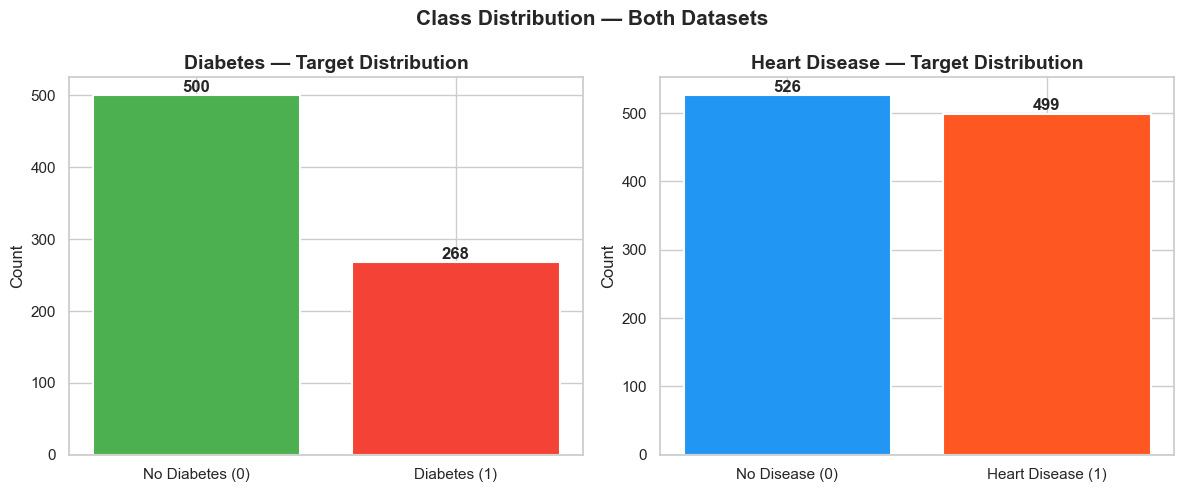

In [28]:
# ── 4.1 TARGET CLASS DISTRIBUTION (both datasets) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diabetes
vals_d = df_diabetes['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], vals_d.values,
            color=['#4CAF50','#F44336'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(vals_d.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Diabetes — Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Heart
vals_h = df_heart['target'].value_counts()
axes[1].bar(['No Disease (0)', 'Heart Disease (1)'], vals_h.values,
            color=['#2196F3','#FF5722'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(vals_h.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('Heart Disease — Target Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution — Both Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

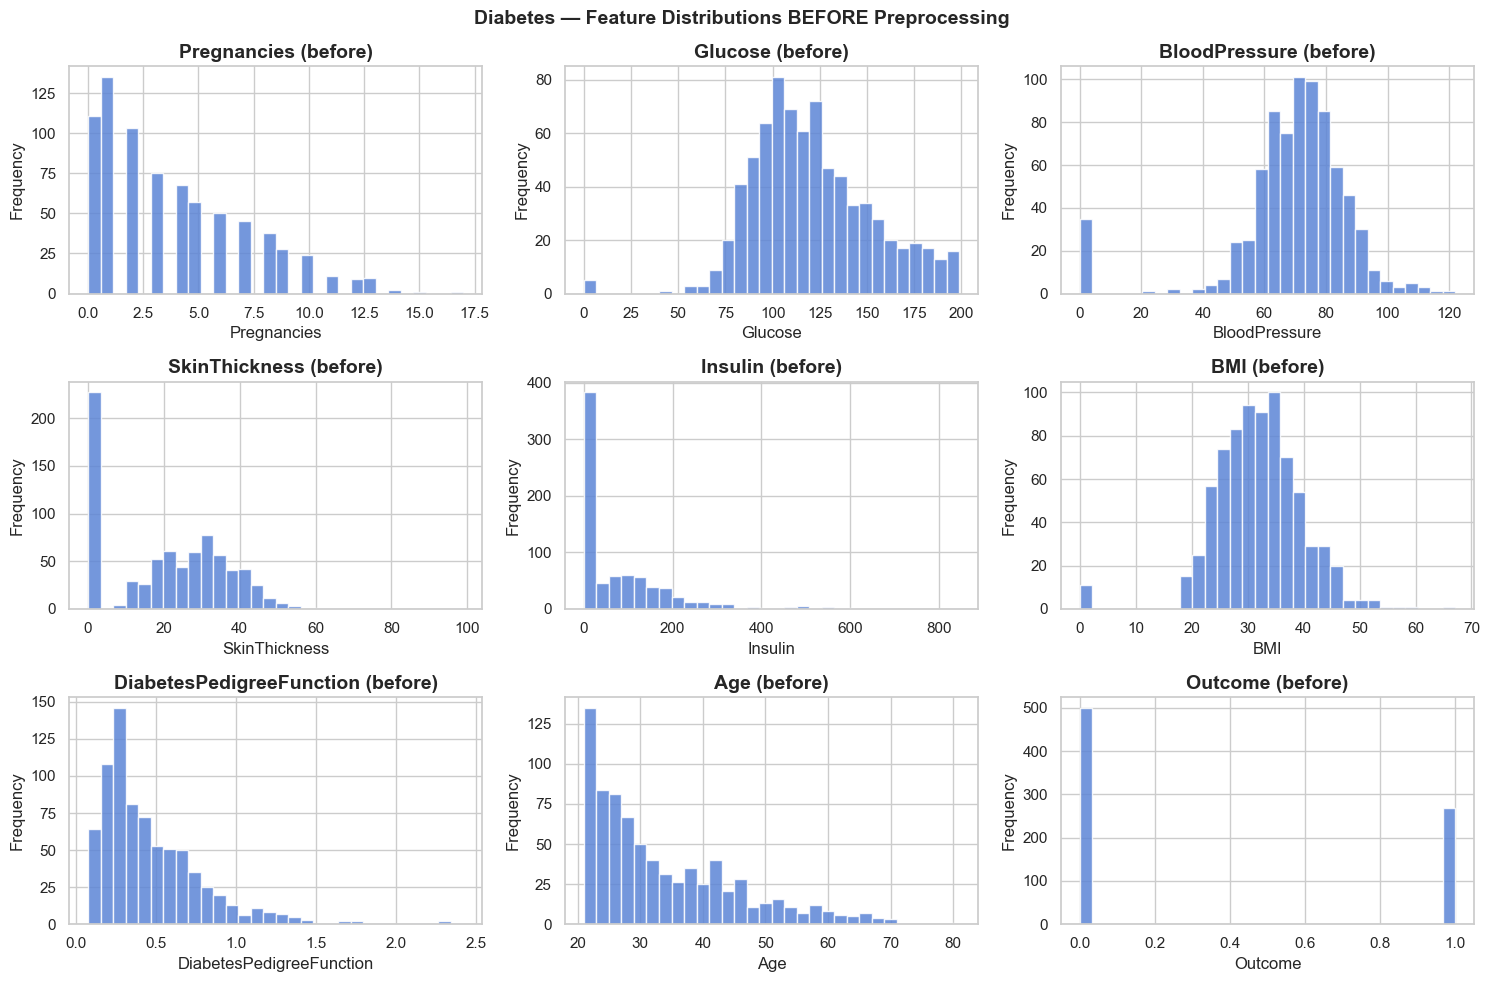

In [29]:
# ── 4.2 HISTOGRAMS — BEFORE PREPROCESSING (Diabetes) ───────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
cols_d = df_diabetes.columns.tolist()
for i, col in enumerate(cols_d):
    axes[i].hist(df_diabetes[col], bins=30, color='#5C85D6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} (before)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Diabetes — Feature Distributions BEFORE Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_hist_diabetes_before.png', dpi=150, bbox_inches='tight')
plt.show()

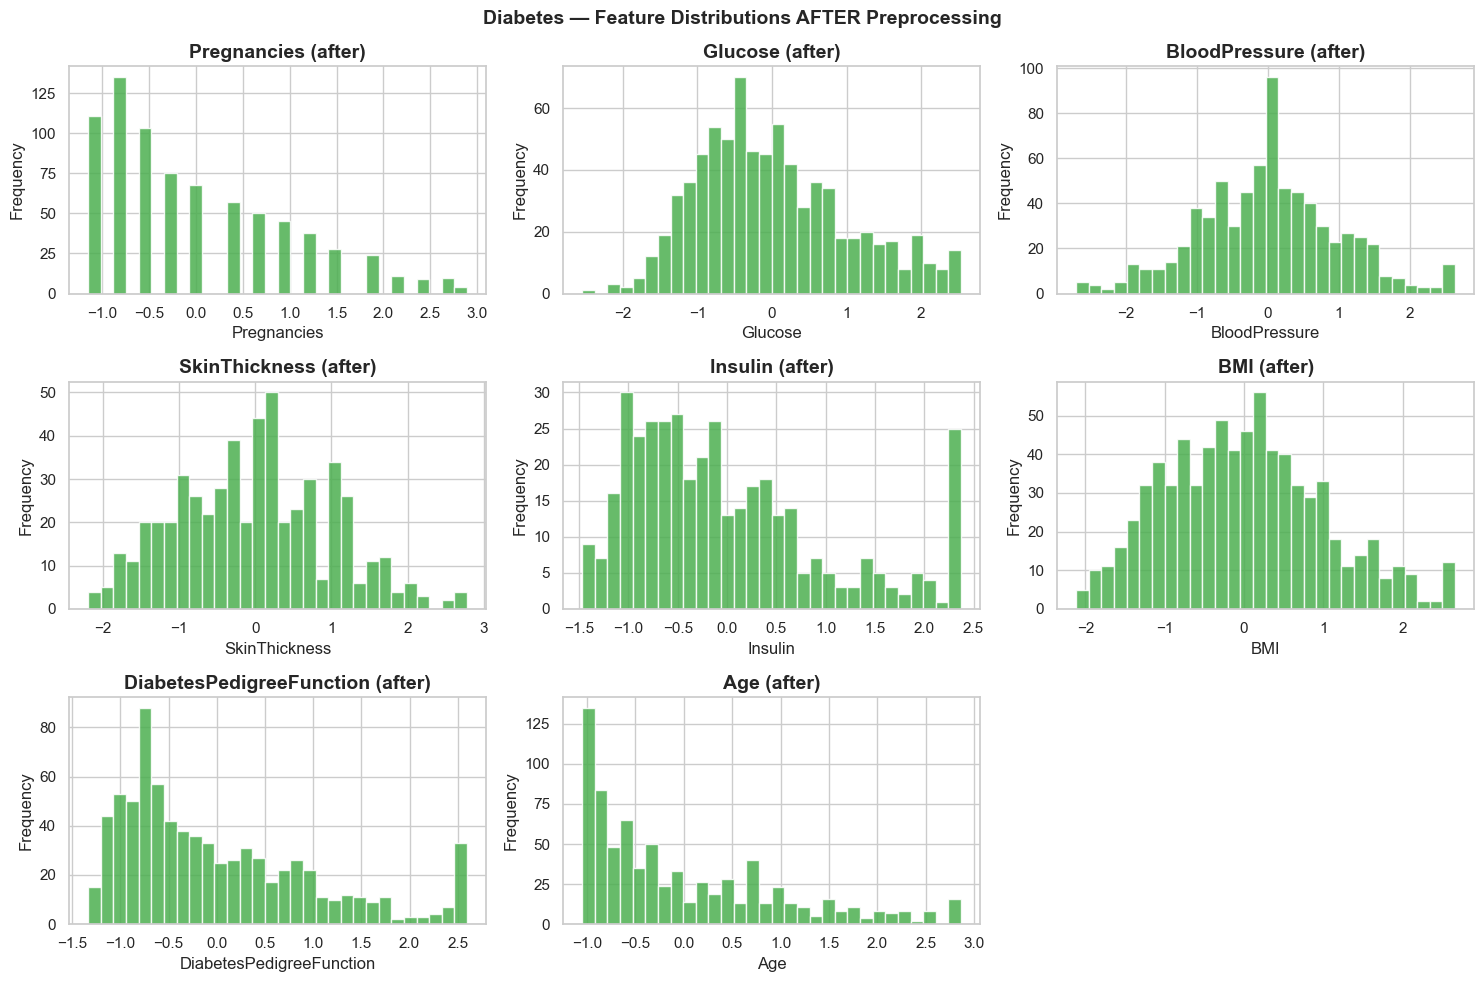

In [30]:
# ── 4.3 HISTOGRAMS — AFTER PREPROCESSING (Diabetes) ────────────────
diab_after = X_d_scaled.copy()
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(X_d_scaled.columns):
    axes[i].hist(X_d_scaled[col], bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} (after)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
if len(X_d_scaled.columns) < 9:
    axes[-1].set_visible(False)
plt.suptitle('Diabetes — Feature Distributions AFTER Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_hist_diabetes_after.png', dpi=150, bbox_inches='tight')
plt.show()

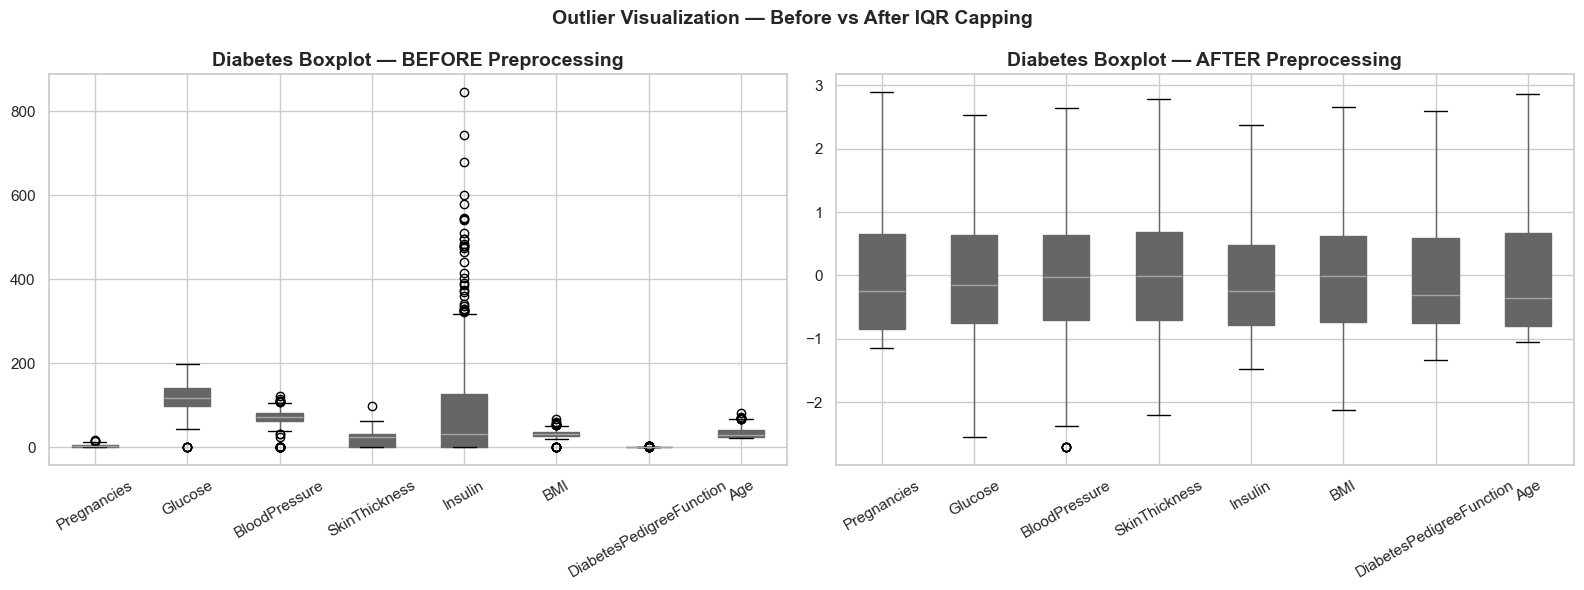

In [31]:
# ── 4.4 BOXPLOTS — OUTLIER BEFORE vs AFTER (Diabetes) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_diabetes[feature_cols_d].boxplot(ax=axes[0], patch_artist=True)
axes[0].set_title('Diabetes Boxplot — BEFORE Preprocessing', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

X_d_scaled.boxplot(ax=axes[1], patch_artist=True)
axes[1].set_title('Diabetes Boxplot — AFTER Preprocessing', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Outlier Visualization — Before vs After IQR Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_boxplot_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

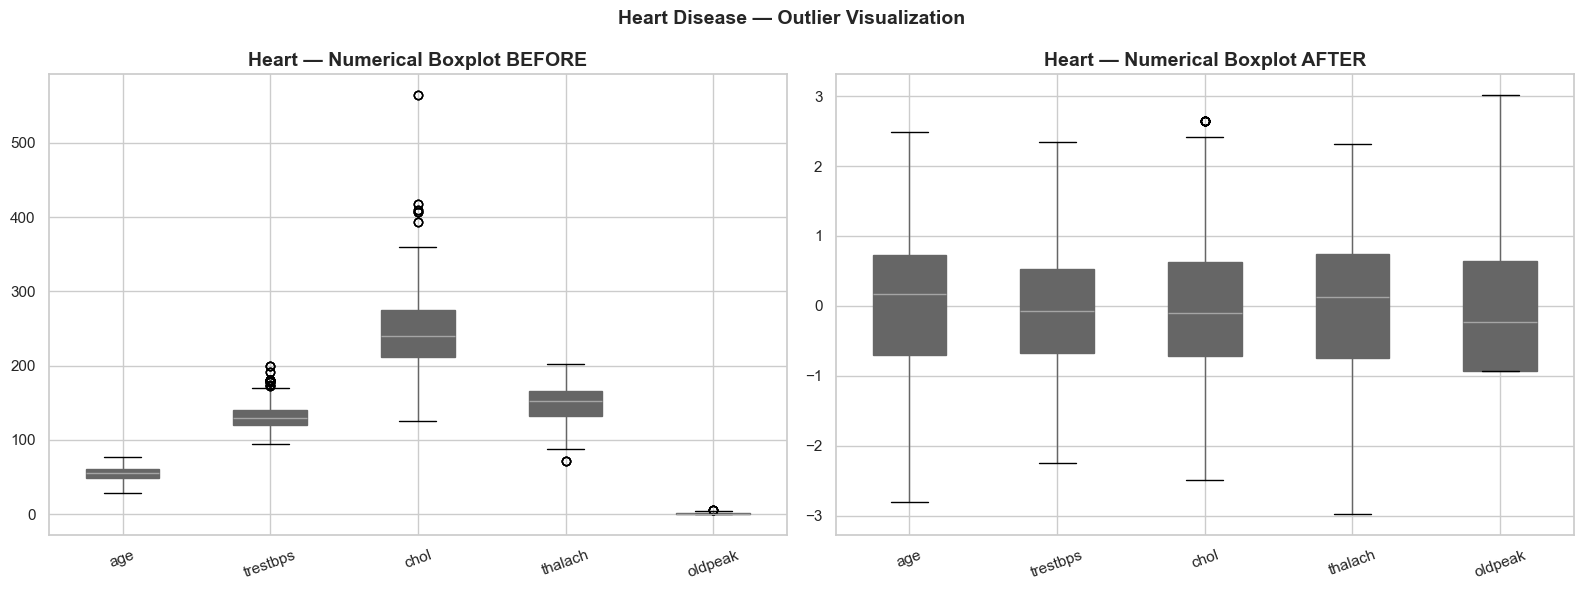

In [32]:
# ── 4.5 BOXPLOTS — Heart Disease ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_heart[num_cols_h].boxplot(ax=axes[0], patch_artist=True)
axes[0].set_title('Heart — Numerical Boxplot BEFORE', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

X_h_scaled[num_cols_h].boxplot(ax=axes[1], patch_artist=True)
axes[1].set_title('Heart — Numerical Boxplot AFTER', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Heart Disease — Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_boxplot_heart.png', dpi=150, bbox_inches='tight')
plt.show()

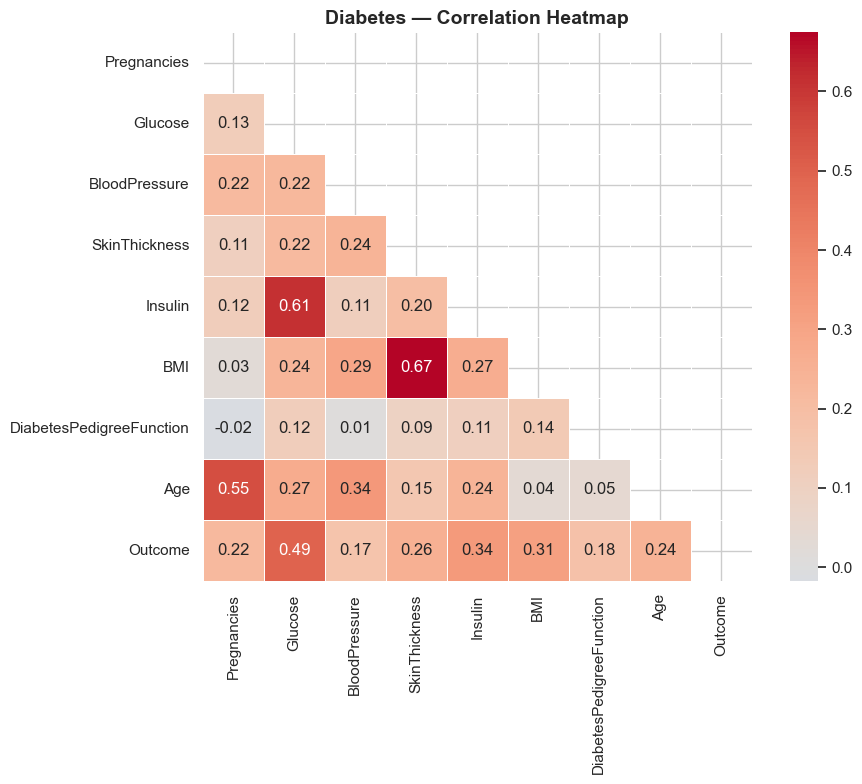

In [33]:
# ── 4.6 CORRELATION HEATMAP — Diabetes ──────────────────────────────
plt.figure(figsize=(10, 8))
corr_d = diab.corr()
mask = np.triu(np.ones_like(corr_d, dtype=bool))
sns.heatmap(corr_d, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Diabetes — Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_heatmap_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

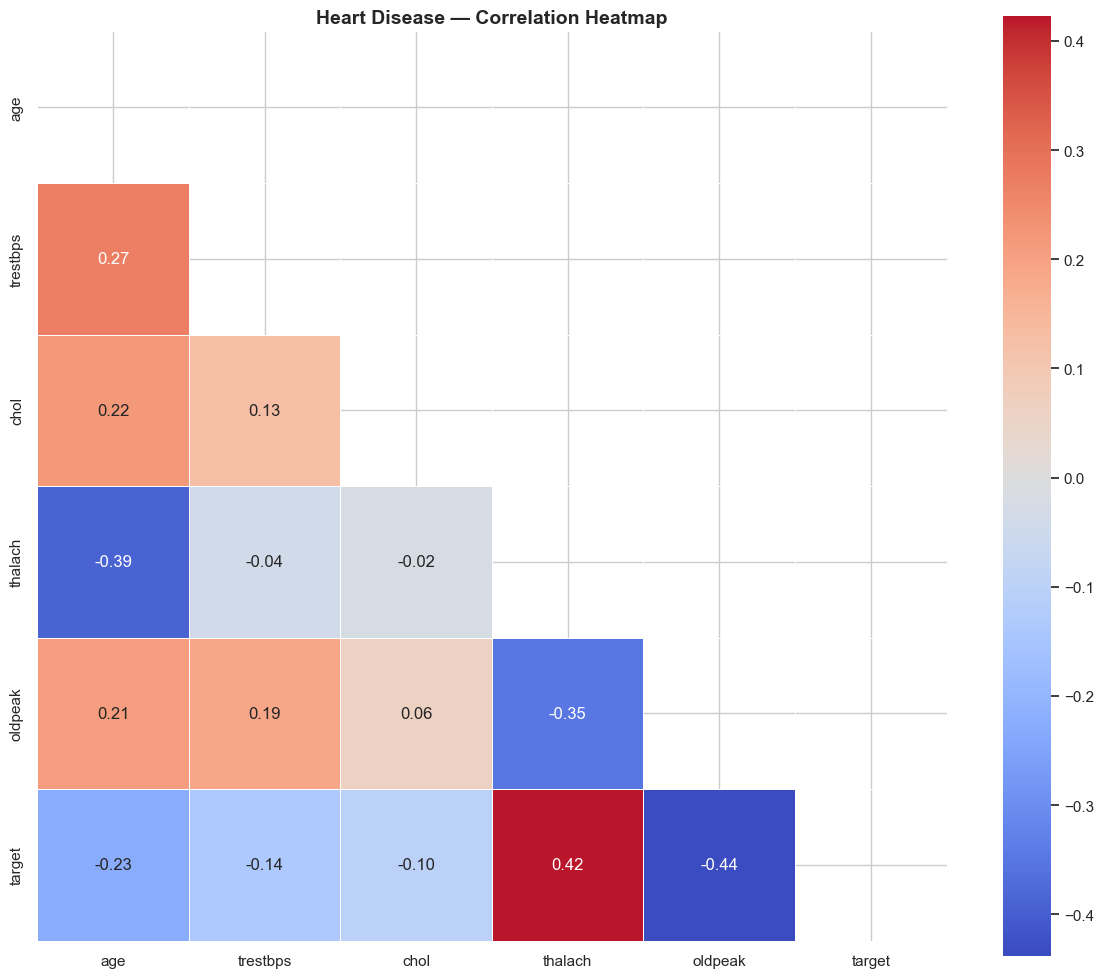

In [34]:
# ── 4.7 CORRELATION HEATMAP — Heart ─────────────────────────────────
plt.figure(figsize=(12, 10))
corr_h = df_heart[['age','trestbps','chol','thalach','oldpeak','target']].corr()
mask = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Heart Disease — Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_heatmap_heart.png', dpi=150, bbox_inches='tight')
plt.show()

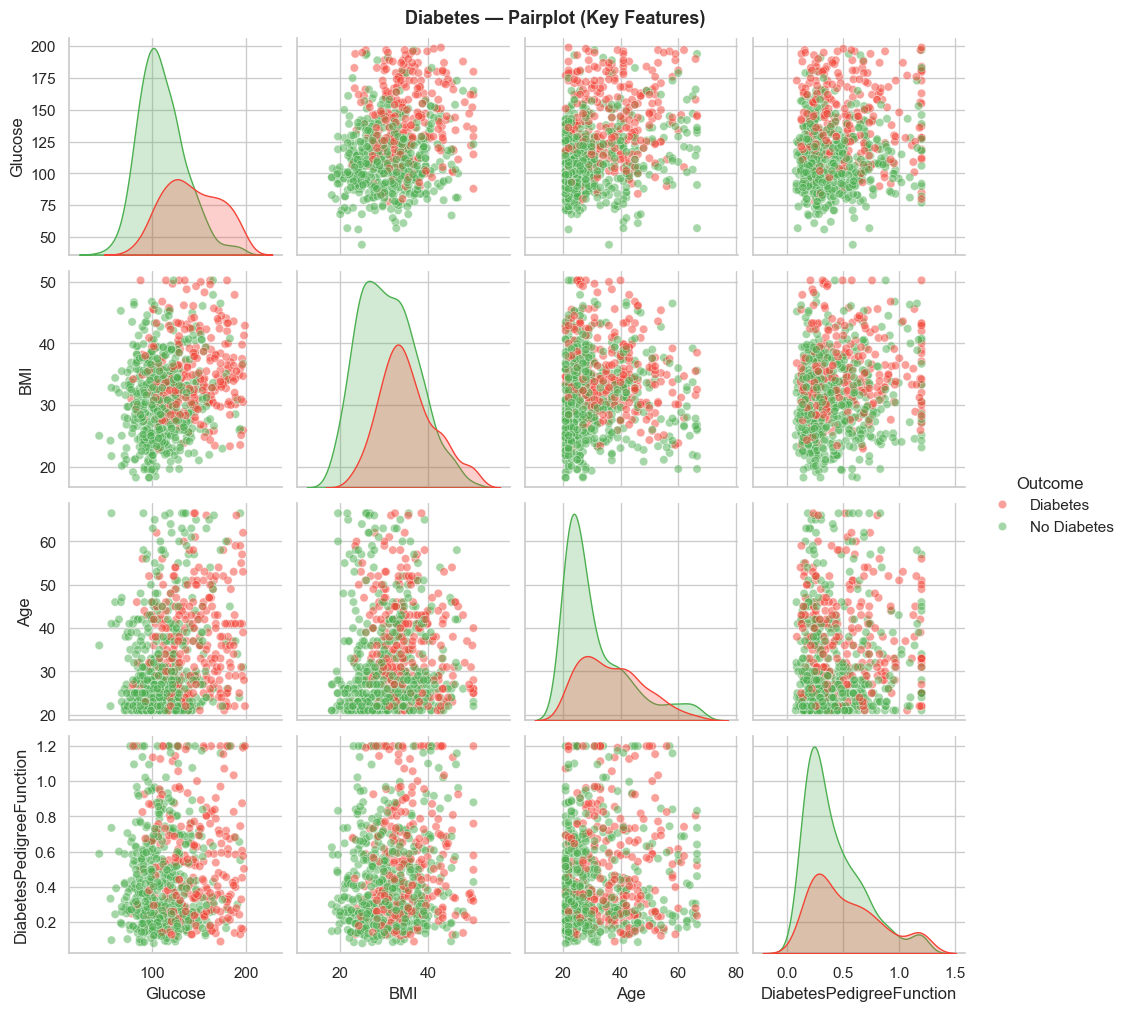

In [35]:
# ── 4.8 PAIRPLOT — Diabetes ──────────────────────────────────────────
key_cols_d = ['Glucose','BMI','Age','DiabetesPedigreeFunction','Outcome']
pair_d = diab[key_cols_d].copy()
pair_d['Outcome'] = pair_d['Outcome'].map({0:'No Diabetes', 1:'Diabetes'})
pp = sns.pairplot(pair_d, hue='Outcome', palette={'No Diabetes':'#4CAF50','Diabetes':'#F44336'},
                  plot_kws={'alpha':0.5}, diag_kind='kde')
pp.fig.suptitle('Diabetes — Pairplot (Key Features)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../models/plot_pairplot_diabetes.png', dpi=120, bbox_inches='tight')
plt.show()

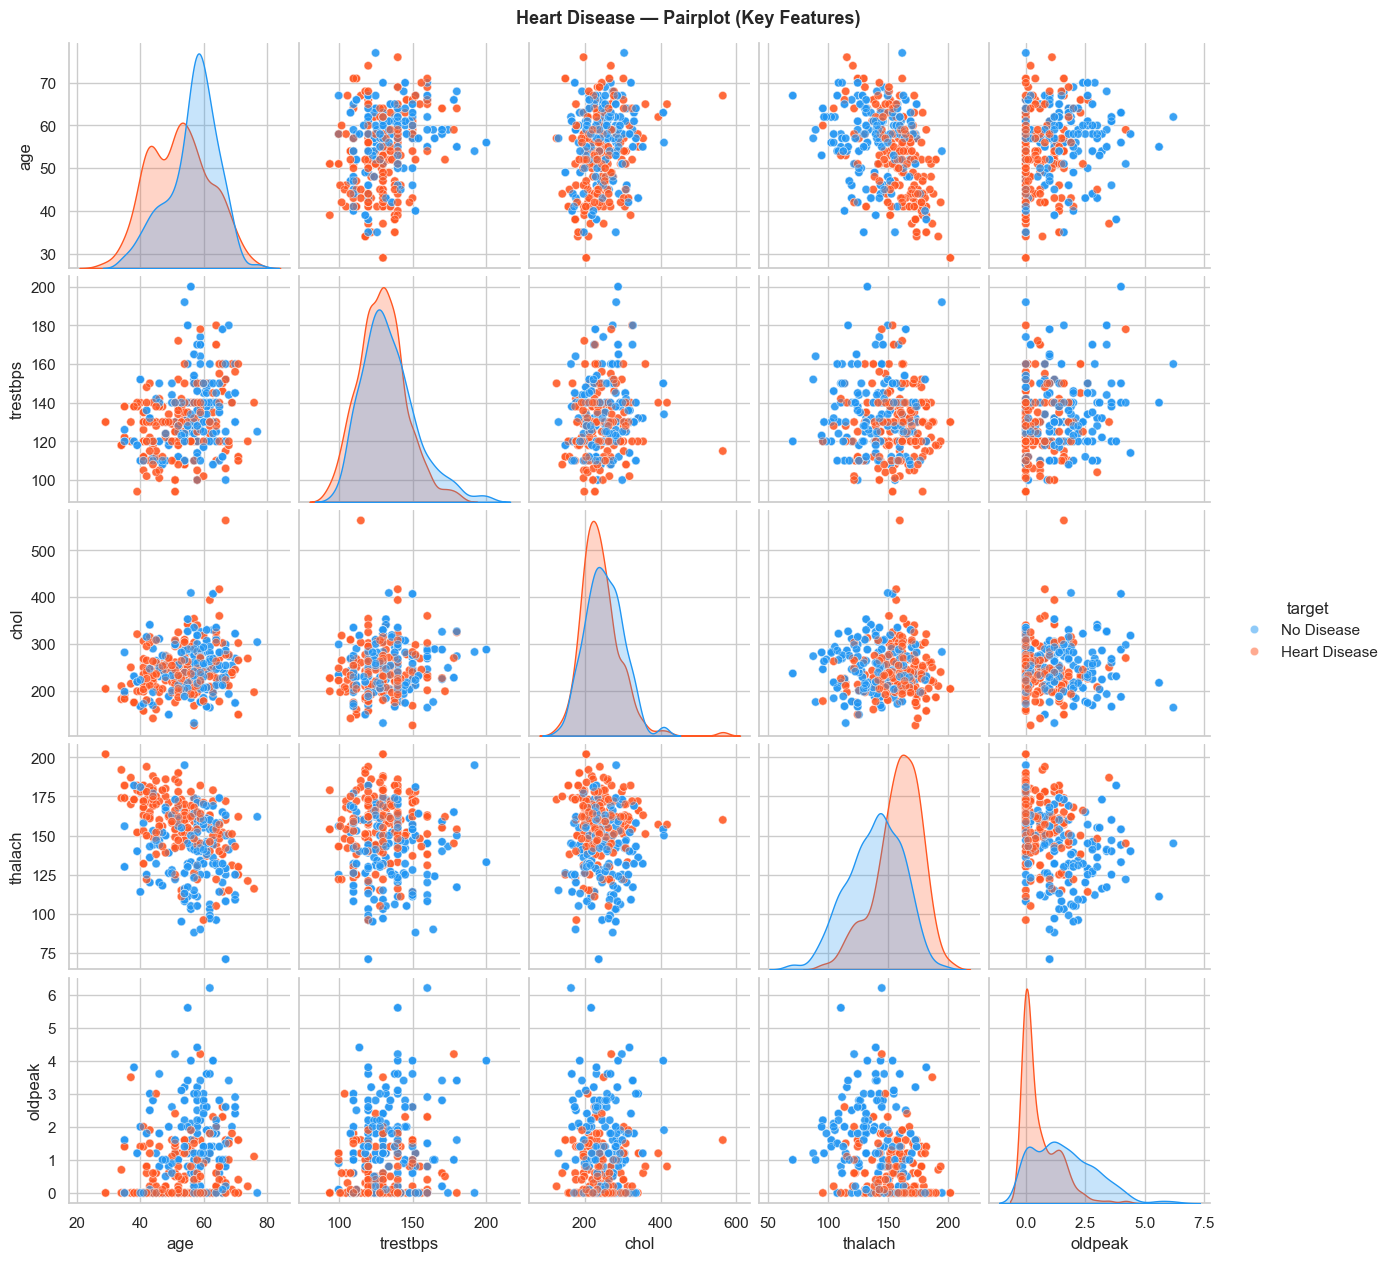

In [36]:
# ── 4.9 PAIRPLOT — Heart ─────────────────────────────────────────────
key_cols_h = ['age','trestbps','chol','thalach','oldpeak','target']
pair_h = df_heart[key_cols_h].copy()
pair_h['target'] = pair_h['target'].map({0:'No Disease', 1:'Heart Disease'})
pp2 = sns.pairplot(pair_h, hue='target', palette={'No Disease':'#2196F3','Heart Disease':'#FF5722'},
                   plot_kws={'alpha':0.5}, diag_kind='kde')
pp2.fig.suptitle('Heart Disease — Pairplot (Key Features)', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../models/plot_pairplot_heart.png', dpi=120, bbox_inches='tight')
plt.show()

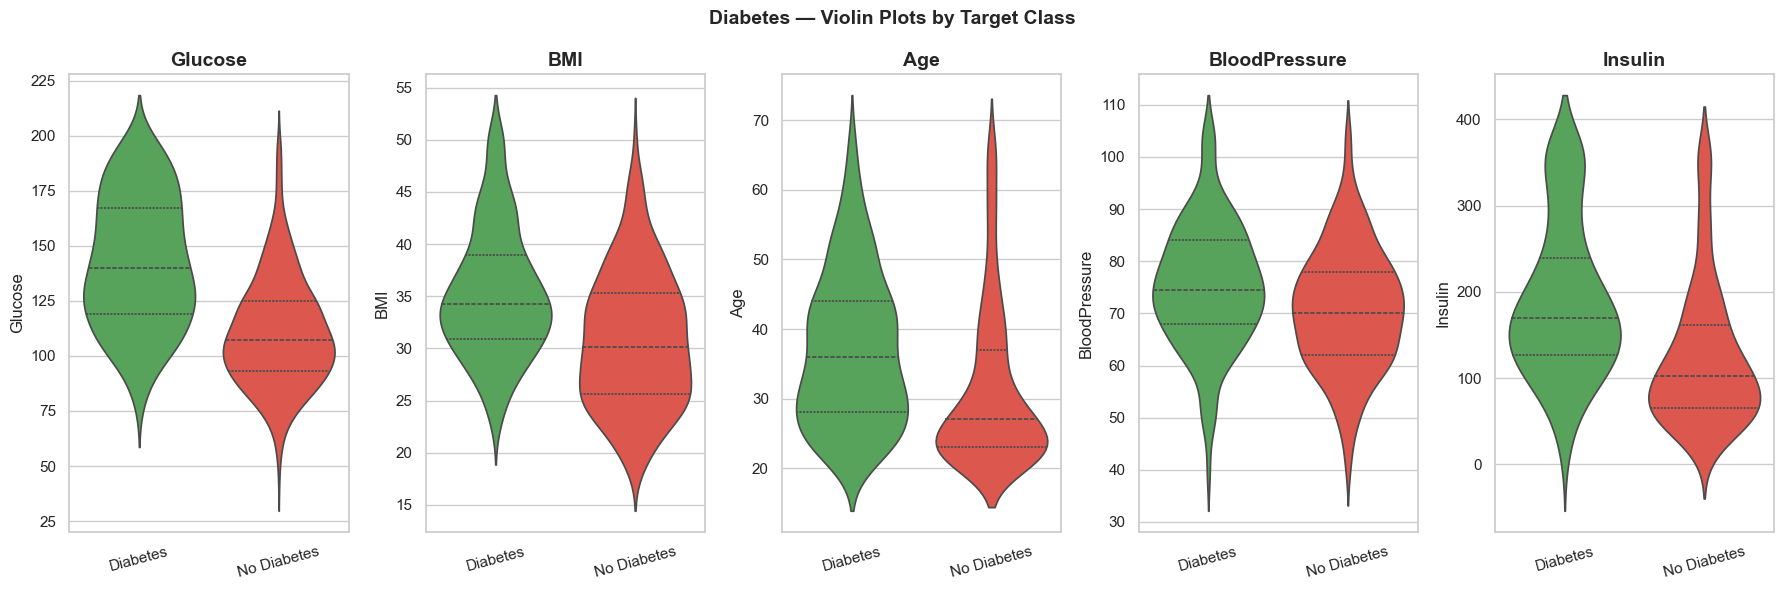

In [37]:
# ── 4.10 VIOLIN PLOTS — Diabetes ─────────────────────────────────────
feat_d_v = ['Glucose','BMI','Age','BloodPressure','Insulin']
fig, axes = plt.subplots(1, len(feat_d_v), figsize=(18, 6))
diab_plot = diab.copy()
diab_plot['Outcome'] = diab_plot['Outcome'].map({0:'No Diabetes', 1:'Diabetes'})
for i, col in enumerate(feat_d_v):
    sns.violinplot(data=diab_plot, x='Outcome', y=col,
                   palette=['#4CAF50','#F44336'], ax=axes[i], inner='quartile')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Diabetes — Violin Plots by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_violin_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

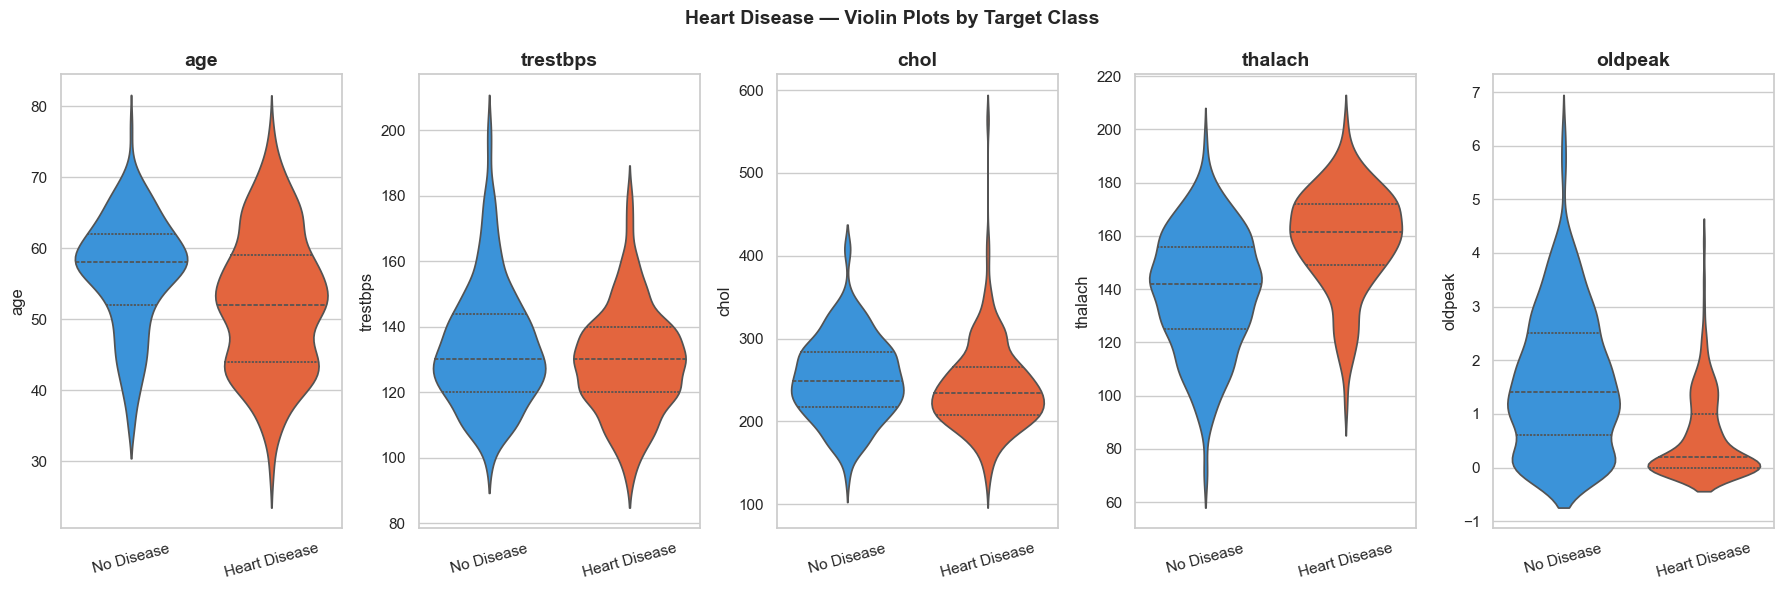

In [38]:
# ── 4.11 VIOLIN PLOTS — Heart ────────────────────────────────────────
feat_h_v = ['age','trestbps','chol','thalach','oldpeak']
fig, axes = plt.subplots(1, len(feat_h_v), figsize=(18, 6))
heart_plot = df_heart.copy()
heart_plot['target'] = heart_plot['target'].map({0:'No Disease', 1:'Heart Disease'})
for i, col in enumerate(feat_h_v):
    sns.violinplot(data=heart_plot, x='target', y=col,
                   palette=['#2196F3','#FF5722'], ax=axes[i], inner='quartile')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Heart Disease — Violin Plots by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_violin_heart.png', dpi=150, bbox_inches='tight')
plt.show()

# Phase 5 — PCA (Feature Selection + Visualization)

NaN check before PCA: 652
NaN after fix: 0


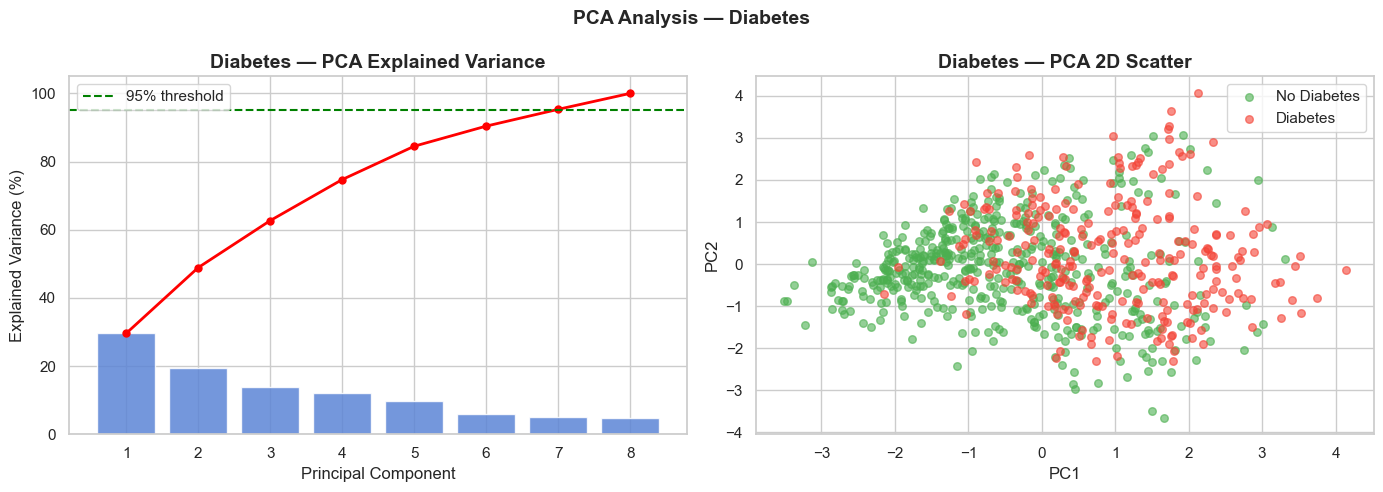

Diabetes: 7 components explain 95% variance
PCA saved ✅


In [39]:
# ── PCA — Diabetes ───────────────────────────────────────────────────

# ✅ Safety check — confirm no NaN before PCA
print("NaN check before PCA:", X_d_scaled.isnull().sum().sum())
X_d_scaled = X_d_scaled.fillna(X_d_scaled.median())
print("NaN after fix:", X_d_scaled.isnull().sum().sum())

pca_d = PCA(n_components=None, random_state=42)
pca_d.fit(X_d_scaled)
explained_d  = pca_d.explained_variance_ratio_
cumulative_d = np.cumsum(explained_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_d)+1), explained_d * 100, color='#5C85D6', alpha=0.85)
axes[0].plot(range(1, len(cumulative_d)+1), cumulative_d * 100, 'r-o', linewidth=2, markersize=5)
axes[0].axhline(y=95, color='green', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Diabetes — PCA Explained Variance', fontweight='bold')
axes[0].legend()

pca_d2   = PCA(n_components=2, random_state=42)
X_d_pca  = pca_d2.fit_transform(X_d_scaled)
colors   = {0: '#4CAF50', 1: '#F44336'}
for cls, label in {0: 'No Diabetes', 1: 'Diabetes'}.items():
    mask = y_d.values == cls
    axes[1].scatter(X_d_pca[mask, 0], X_d_pca[mask, 1],
                    c=colors[cls], label=label, alpha=0.6, s=30)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Diabetes — PCA 2D Scatter', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA Analysis — Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_pca_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

# Select components for 95% variance
n_comp_d = np.argmax(cumulative_d >= 0.95) + 1
print(f'Diabetes: {n_comp_d} components explain 95% variance')

# ✅ FIX ADDED HERE — clean NaN from train/test splits
X_d_train = pd.DataFrame(X_d_train).fillna(pd.DataFrame(X_d_train).median()).values
X_d_test  = pd.DataFrame(X_d_test).fillna(pd.DataFrame(X_d_test).median()).values

pca_d_final   = PCA(n_components=n_comp_d, random_state=42)
X_d_train_pca = pca_d_final.fit_transform(X_d_train)
X_d_test_pca  = pca_d_final.transform(X_d_test)
joblib.dump(pca_d_final, MODEL_PATH + 'pca_diabetes.pkl')
print('PCA saved ✅')

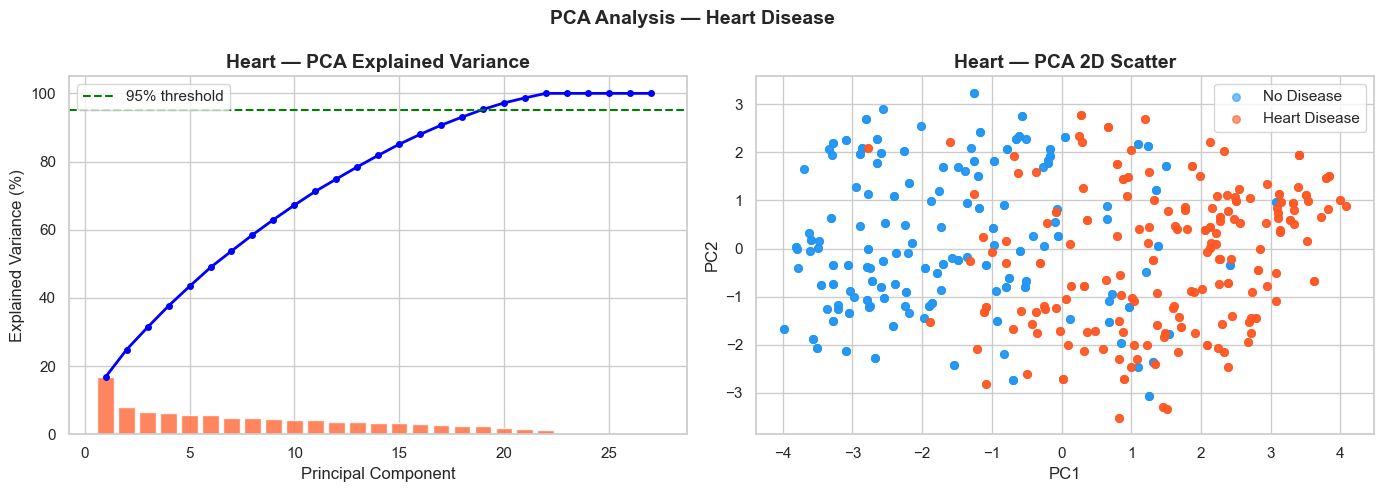

Heart: 19 components explain 95% variance
PCA saved ✅


In [40]:
# ── PCA — Heart ──────────────────────────────────────────────────────
pca_h = PCA(n_components=None, random_state=42)
pca_h.fit(X_h_scaled)
explained_h = pca_h.explained_variance_ratio_
cumulative_h = np.cumsum(explained_h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_h)+1), explained_h * 100, color='#FF7043', alpha=0.85)
axes[0].plot(range(1, len(cumulative_h)+1), cumulative_h * 100, 'b-o', linewidth=2, markersize=4)
axes[0].axhline(y=95, color='green', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Heart — PCA Explained Variance', fontweight='bold')
axes[0].legend()

pca_h2 = PCA(n_components=2, random_state=42)
X_h_pca = pca_h2.fit_transform(X_h_scaled)
colors_h = {0:'#2196F3', 1:'#FF5722'}
for cls, label in {0:'No Disease', 1:'Heart Disease'}.items():
    mask = y_h.values == cls
    axes[1].scatter(X_h_pca[mask, 0], X_h_pca[mask, 1],
                    c=colors_h[cls], label=label, alpha=0.6, s=30)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Heart — PCA 2D Scatter', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA Analysis — Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_pca_heart.png', dpi=150, bbox_inches='tight')
plt.show()

n_comp_h = np.argmax(cumulative_h >= 0.95) + 1
print(f'Heart: {n_comp_h} components explain 95% variance')
pca_h_final = PCA(n_components=n_comp_h, random_state=42)
X_h_train_pca = pca_h_final.fit_transform(X_h_train)
X_h_test_pca  = pca_h_final.transform(X_h_test)
joblib.dump(pca_h_final, MODEL_PATH + 'pca_heart.pkl')
print('PCA saved ✅')

# Phase 6 — Model Training & Evaluation

In [41]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, label=''):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)
    print(f'\n--- {label} | {name} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(classification_report(y_te, y_pred))
    return {'model': model, 'name': name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm, 'y_pred': y_pred}

print('Helper function defined ✅')

Helper function defined ✅


In [42]:
# ── Train all 3 models on DIABETES ───────────────────────────────────
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('KNN',                 KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=42)),
]

results_d = []
for name, model in models:
    r = evaluate_model(name, model, X_d_train, y_d_train, X_d_test, y_d_test, label='DIABETES')
    results_d.append(r)

# Save models
for r in results_d:
    safe_name = r['name'].replace(' ','_').lower()
    joblib.dump(r['model'], MODEL_PATH + f'{safe_name}_diabetes.pkl')
print('\n✅ All Diabetes models trained and saved!')


--- DIABETES | Logistic Regression ---
  Accuracy : 0.6948
  Precision: 0.5778
  Recall   : 0.4815
  F1-Score : 0.5253
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       100
           1       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


--- DIABETES | KNN ---
  Accuracy : 0.7662
  Precision: 0.7045
  Recall   : 0.5741
  F1-Score : 0.6327
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       100
           1       0.70      0.57      0.63        54

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154


--- DIABETES | Decision Tree ---
  Accuracy : 0.7662
  Precision: 0.6452
  Recall   : 0.7407
  F1-Score : 0.6897
        

In [43]:
# ── Train all 3 models on HEART ───────────────────────────────────────
results_h = []
for name, model in models:
    m = type(model)(**model.get_params())
    r = evaluate_model(name, m, X_h_train, y_h_train, X_h_test, y_h_test, label='HEART')
    results_h.append(r)

for r in results_h:
    safe_name = r['name'].replace(' ','_').lower()
    joblib.dump(r['model'], MODEL_PATH + f'{safe_name}_heart.pkl')
print('\n✅ All Heart models trained and saved!')


--- HEART | Logistic Regression ---
  Accuracy : 0.8829
  Precision: 0.8584
  Recall   : 0.9238
  F1-Score : 0.8899
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       100
           1       0.86      0.92      0.89       105

    accuracy                           0.88       205
   macro avg       0.89      0.88      0.88       205
weighted avg       0.89      0.88      0.88       205




--- HEART | KNN ---
  Accuracy : 0.8390
  Precision: 0.8462
  Recall   : 0.8381
  F1-Score : 0.8421
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.85      0.84      0.84       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205


--- HEART | Decision Tree ---
  Accuracy : 0.8878
  Precision: 0.9100
  Recall   : 0.8667
  F1-Score : 0.8878
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       100
           1       0.91      0.87      0.89       105

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205


✅ All Heart models trained and saved!


## 6.1 Confusion Matrix Heatmaps

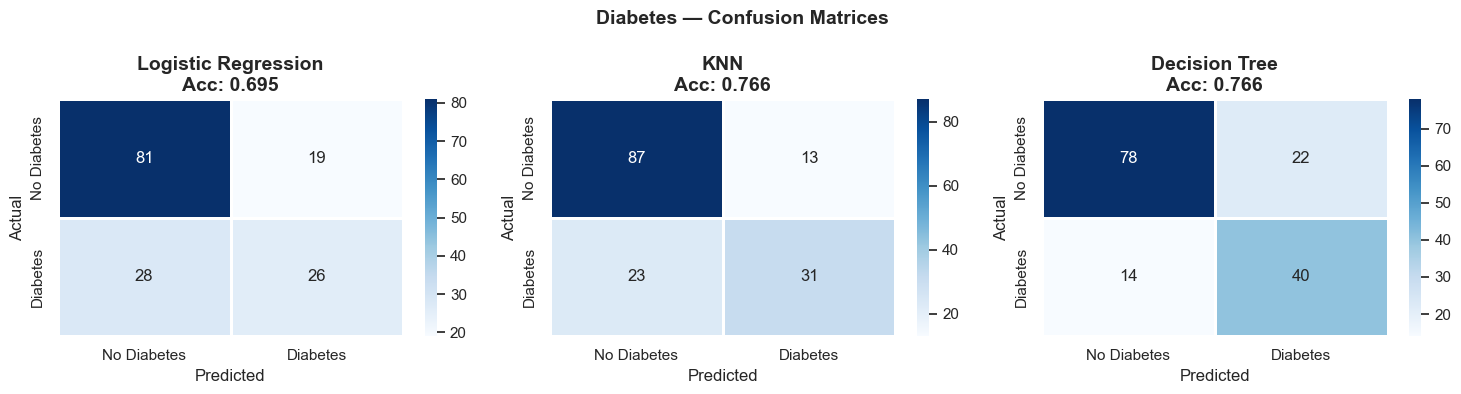

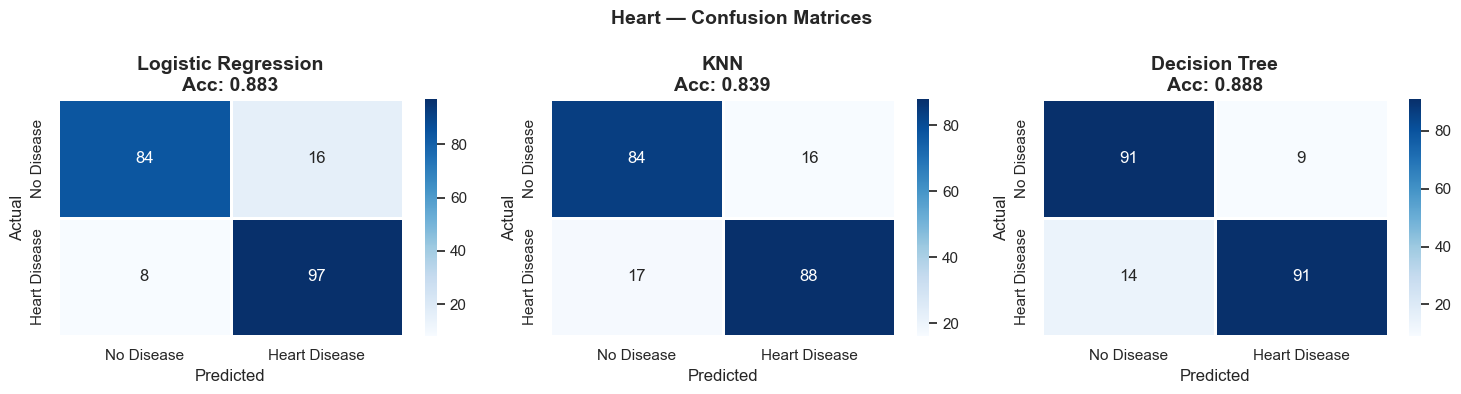

In [44]:
def plot_confusion_matrices(results, dataset_name, class_labels):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, r in enumerate(results):
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_labels, yticklabels=class_labels,
                    ax=axes[i], linewidths=1)
        axes[i].set_title(f"{r['name']}\nAcc: {r['acc']:.3f}", fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    plt.suptitle(f'{dataset_name} — Confusion Matrices', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../models/plot_cm_{dataset_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(results_d, 'Diabetes', ['No Diabetes','Diabetes'])
plot_confusion_matrices(results_h, 'Heart', ['No Disease','Heart Disease'])

## 6.2 Model Comparison Bar Chart

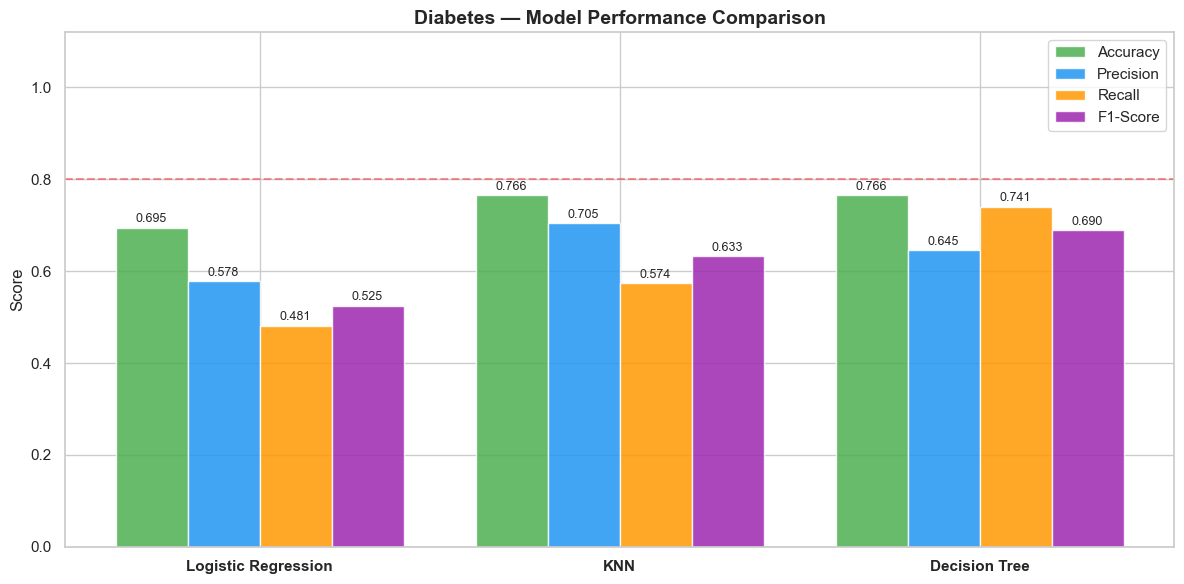

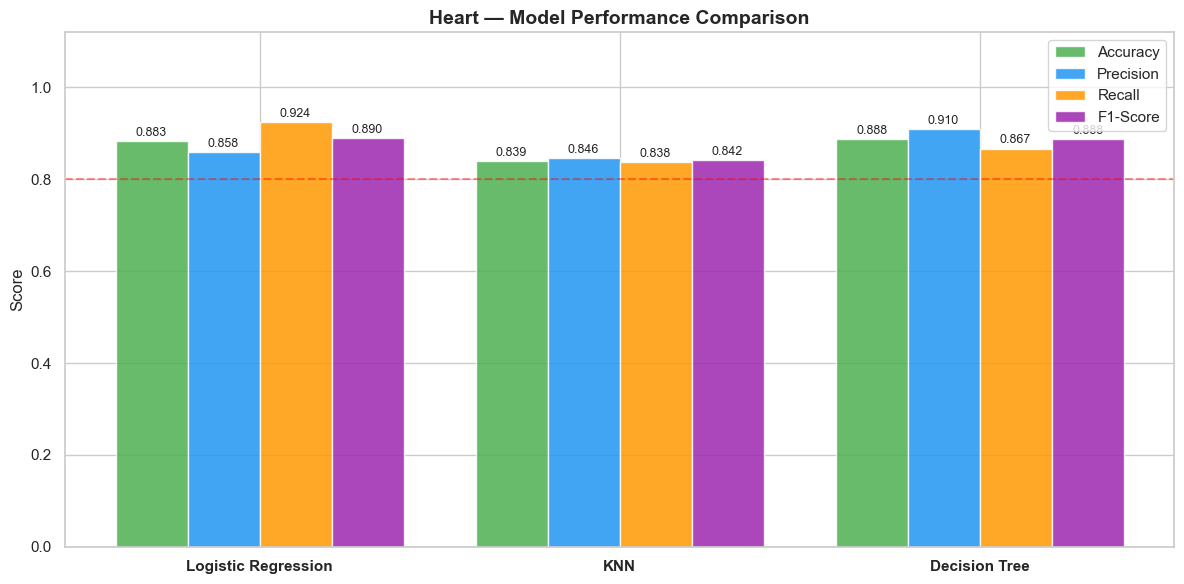

In [45]:
def plot_model_comparison(results, dataset_name):
    names   = [r['name'] for r in results]
    metrics = ['acc', 'prec', 'rec', 'f1']
    labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors  = ['#4CAF50','#2196F3','#FF9800','#9C27B0']
    x = np.arange(len(names))
    width = 0.2
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (m, lbl, col) in enumerate(zip(metrics, labels, colors)):
        vals = [r[m] for r in results]
        bars = ax.bar(x + i * width, vals, width, label=lbl, color=col, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(names, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.set_title(f'{dataset_name} — Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='0.80 threshold')
    plt.tight_layout()
    plt.savefig(f'../models/plot_comparison_{dataset_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_model_comparison(results_d, 'Diabetes')
plot_model_comparison(results_h, 'Heart')

## 6.3 ROC Curves

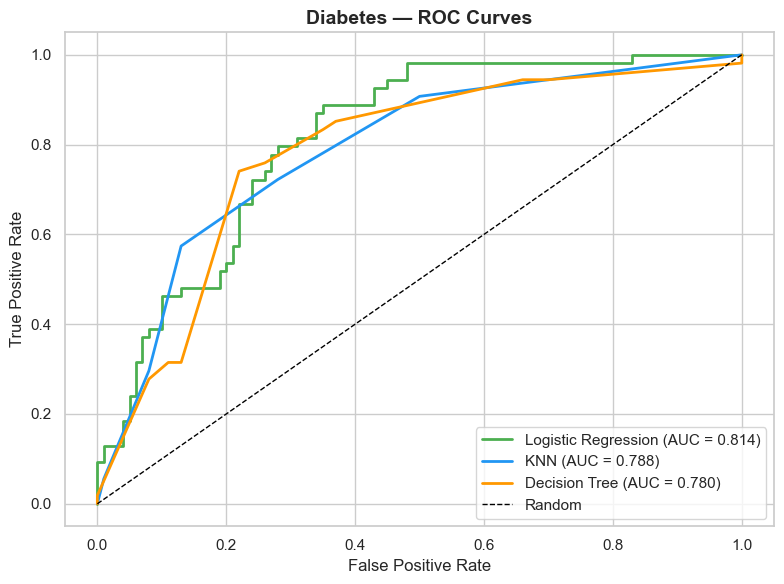

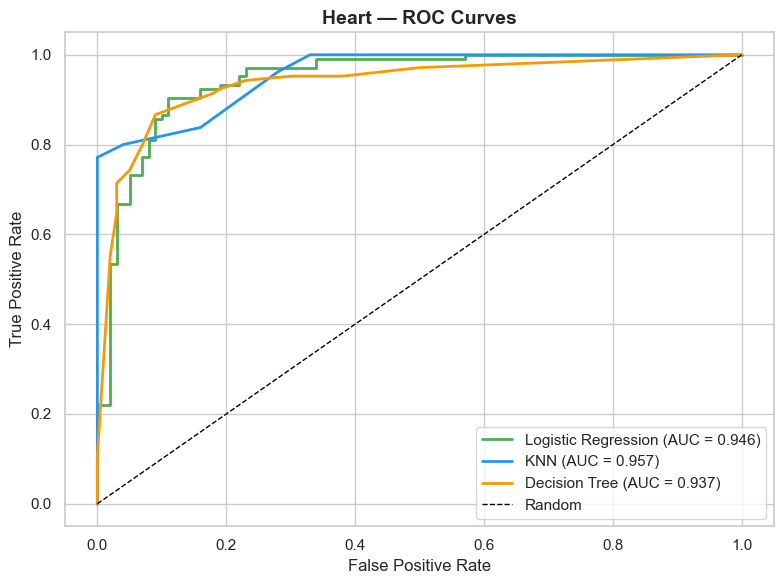

In [46]:
def plot_roc_curves(results, X_test, y_test, dataset_name):
    plt.figure(figsize=(8, 6))
    colors = ['#4CAF50','#2196F3','#FF9800']
    for r, col in zip(results, colors):
        if hasattr(r['model'], 'predict_proba'):
            y_prob = r['model'].predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=col, lw=2,
                     label=f"{r['name']} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{dataset_name} — ROC Curves', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'../models/plot_roc_{dataset_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_roc_curves(results_d, X_d_test, y_d_test, 'Diabetes')
plot_roc_curves(results_h, X_h_test, y_h_test, 'Heart')

## 6.4 Feature Importance

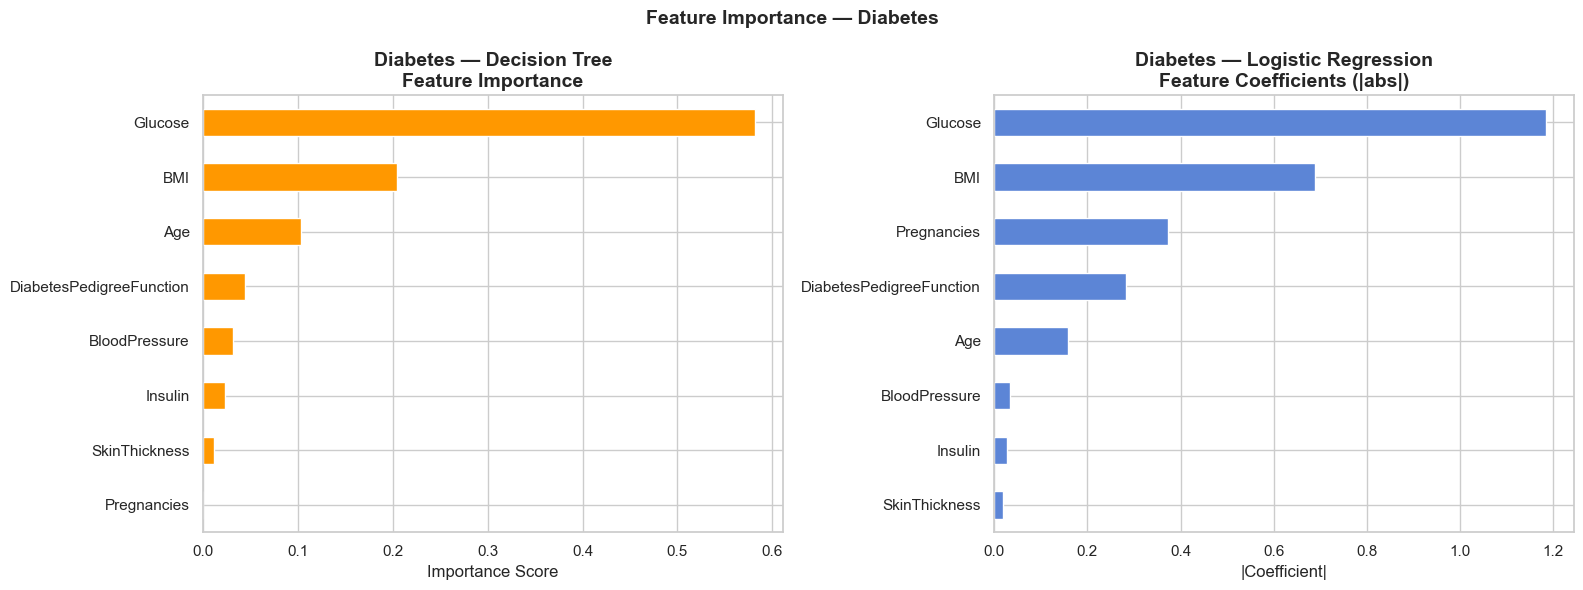

In [47]:
# ── Feature Importance — Diabetes ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree importance
dt_d = next(r['model'] for r in results_d if r['name'] == 'Decision Tree')
dt_imp = pd.Series(dt_d.feature_importances_, index=X_d.columns).sort_values(ascending=True)
dt_imp.plot(kind='barh', ax=axes[0], color='#FF9800', edgecolor='white')
axes[0].set_title('Diabetes — Decision Tree\nFeature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Logistic Regression coefficients
lr_d = next(r['model'] for r in results_d if r['name'] == 'Logistic Regression')
lr_coef = pd.Series(np.abs(lr_d.coef_[0]), index=X_d.columns).sort_values(ascending=True)
lr_coef.plot(kind='barh', ax=axes[1], color='#5C85D6', edgecolor='white')
axes[1].set_title('Diabetes — Logistic Regression\nFeature Coefficients (|abs|)', fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance — Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_feature_imp_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

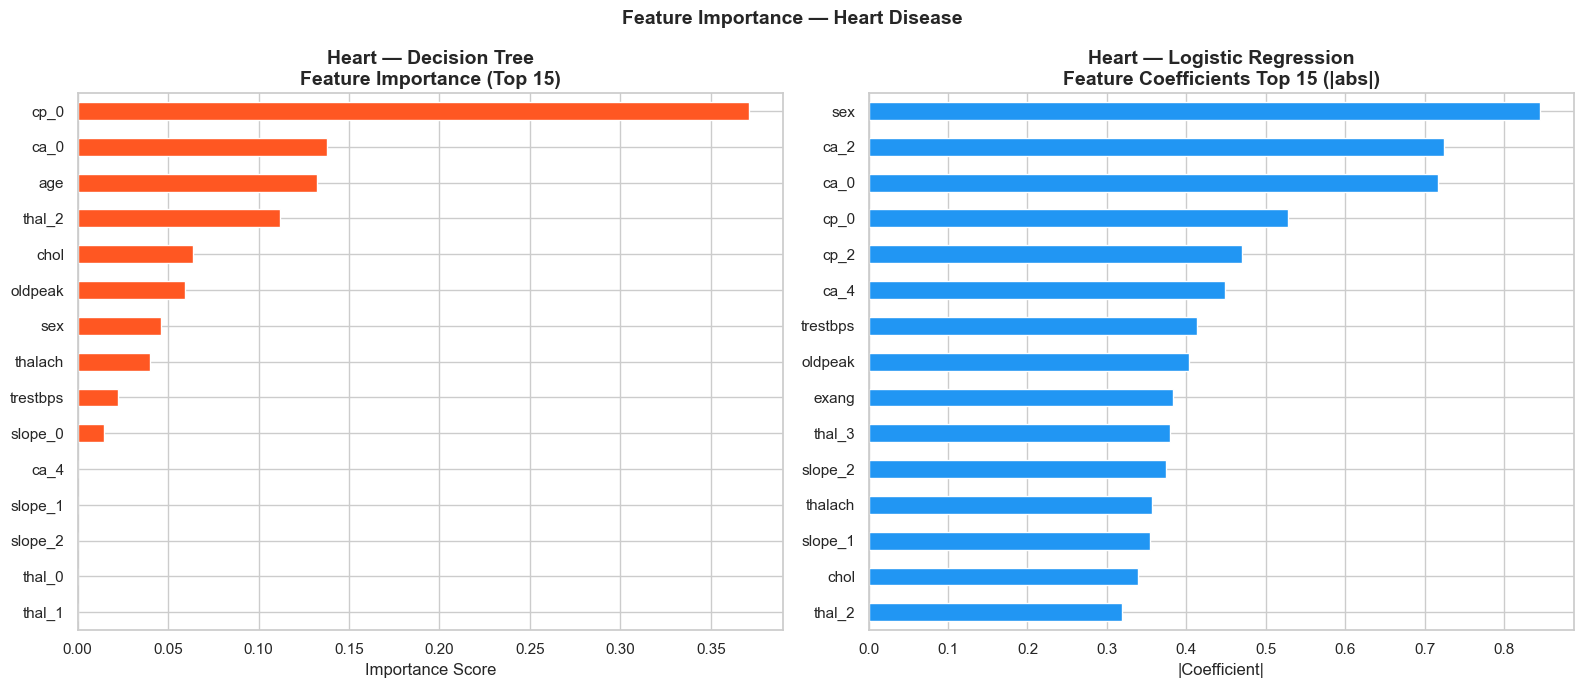

In [48]:
# ── Feature Importance — Heart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dt_h = next(r['model'] for r in results_h if r['name'] == 'Decision Tree')
dt_imp_h = pd.Series(dt_h.feature_importances_, index=X_h.columns).sort_values(ascending=True)
dt_imp_h.tail(15).plot(kind='barh', ax=axes[0], color='#FF5722', edgecolor='white')
axes[0].set_title('Heart — Decision Tree\nFeature Importance (Top 15)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

lr_h = next(r['model'] for r in results_h if r['name'] == 'Logistic Regression')
lr_coef_h = pd.Series(np.abs(lr_h.coef_[0]), index=X_h.columns).sort_values(ascending=True)
lr_coef_h.tail(15).plot(kind='barh', ax=axes[1], color='#2196F3', edgecolor='white')
axes[1].set_title('Heart — Logistic Regression\nFeature Coefficients Top 15 (|abs|)', fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.suptitle('Feature Importance — Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_feature_imp_heart.png', dpi=150, bbox_inches='tight')
plt.show()

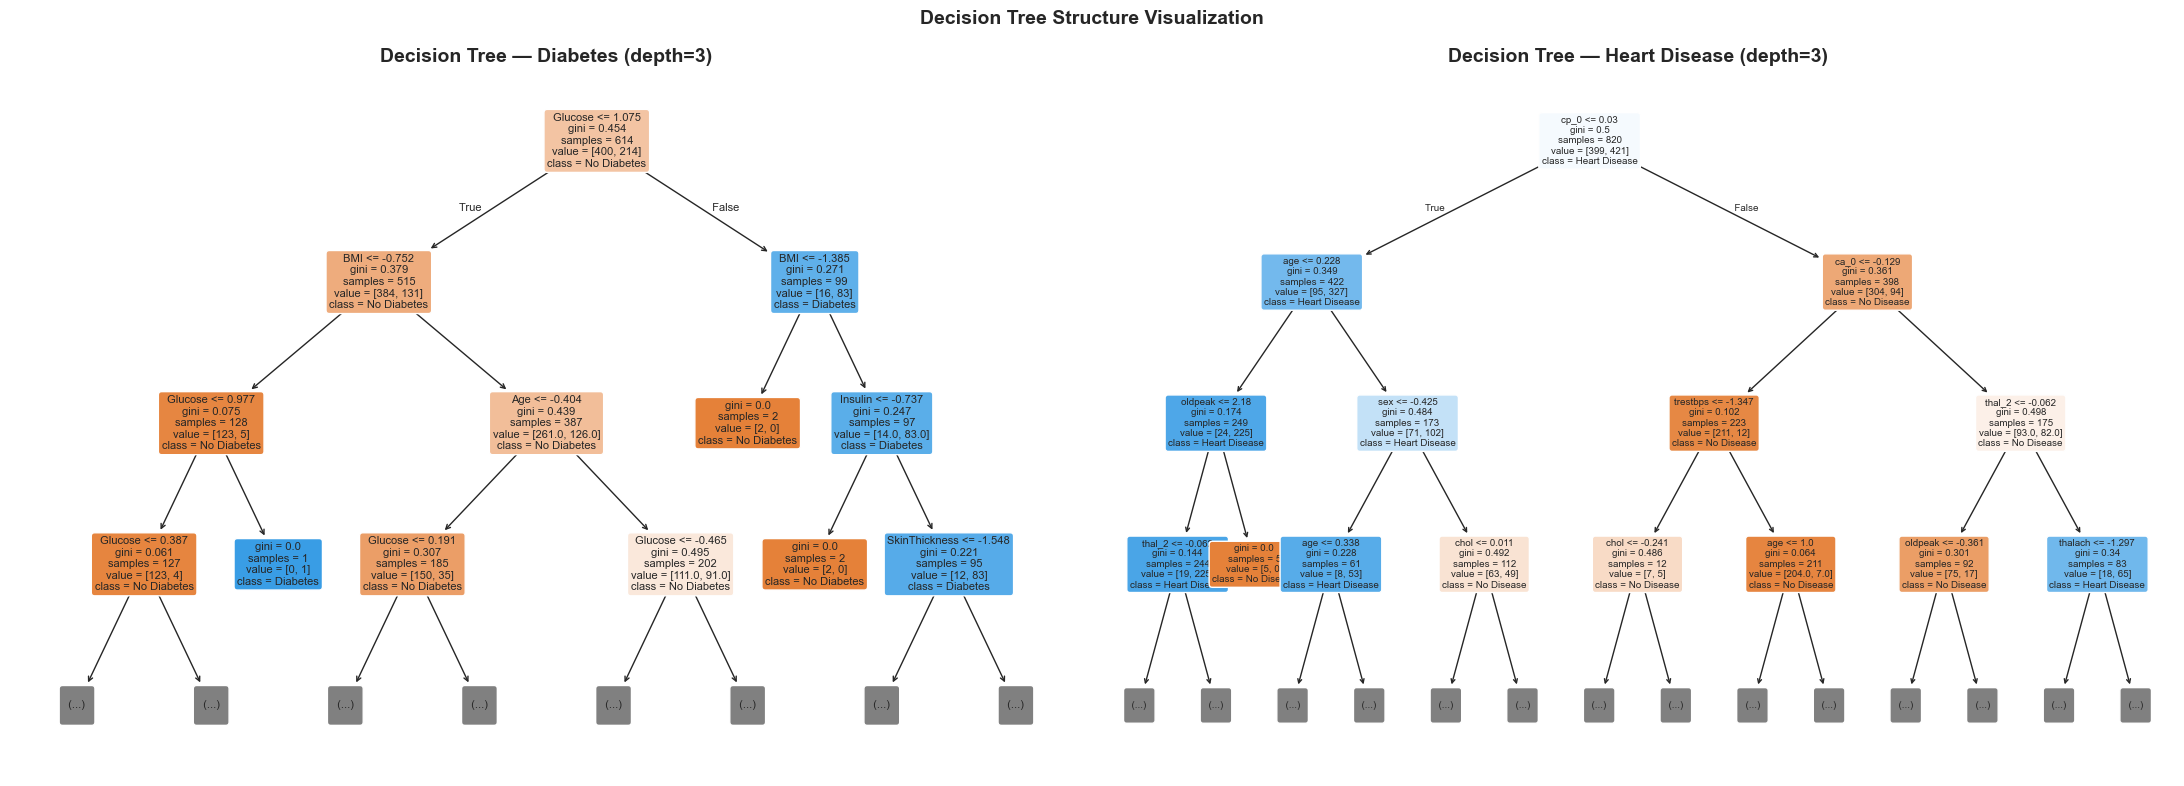

In [49]:
# ── Decision Tree Structure Plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

plot_tree(dt_d, feature_names=list(X_d.columns), class_names=['No Diabetes','Diabetes'],
          filled=True, max_depth=3, ax=axes[0], fontsize=8, rounded=True)
axes[0].set_title('Decision Tree — Diabetes (depth=3)', fontweight='bold')

plot_tree(dt_h, feature_names=list(X_h.columns), class_names=['No Disease','Heart Disease'],
          filled=True, max_depth=3, ax=axes[1], fontsize=7, rounded=True)
axes[1].set_title('Decision Tree — Heart Disease (depth=3)', fontweight='bold')

plt.suptitle('Decision Tree Structure Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/plot_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()

## 6.5 Best Model Selection & Summary

In [50]:
def summarize_results(results, dataset_name):
    print(f'\n{"="*55}')
    print(f'  {dataset_name.upper()} — MODEL PERFORMANCE SUMMARY')
    print(f'{"="*55}')
    df_res = pd.DataFrame([{
        'Model': r['name'],
        'Accuracy':  round(r['acc'],  4),
        'Precision': round(r['prec'], 4),
        'Recall':    round(r['rec'],  4),
        'F1-Score':  round(r['f1'],   4)
    } for r in results])
    print(df_res.to_string(index=False))
    best = max(results, key=lambda r: r['f1'])
    print(f'\n🏆 Best Model (by F1): {best["name"]} — F1={best["f1"]:.4f}')
    return best

best_d = summarize_results(results_d, 'Diabetes')
best_h = summarize_results(results_h, 'Heart Disease')

# Save best model names for Streamlit
import json
with open(MODEL_PATH + 'best_models.json', 'w') as f:
    json.dump({'diabetes': best_d['name'], 'heart': best_h['name']}, f)
print('\n✅ Best model names saved to JSON!')


  DIABETES — MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6948     0.5778  0.4815    0.5253
                KNN    0.7662     0.7045  0.5741    0.6327
      Decision Tree    0.7662     0.6452  0.7407    0.6897

🏆 Best Model (by F1): Decision Tree — F1=0.6897

  HEART DISEASE — MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8829     0.8584  0.9238    0.8899
                KNN    0.8390     0.8462  0.8381    0.8421
      Decision Tree    0.8878     0.9100  0.8667    0.8878

🏆 Best Model (by F1): Logistic Regression — F1=0.8899

✅ Best model names saved to JSON!
